## ------------------------- Support Vector Machine -----------------------

### Importing the libraries

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Importing the datasets

In [19]:
df= pd.read_csv('https://raw.githubusercontent.com/sahdevsaini/Data-Set/main/Social_Network_Ads.csv')

In [20]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [13]:
df.shape

(400, 5)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


### Dependent & Independent Features

In [21]:
X = df.iloc[:, [2,3]].values
y = df.iloc[:, 4].values

### Scatter plot

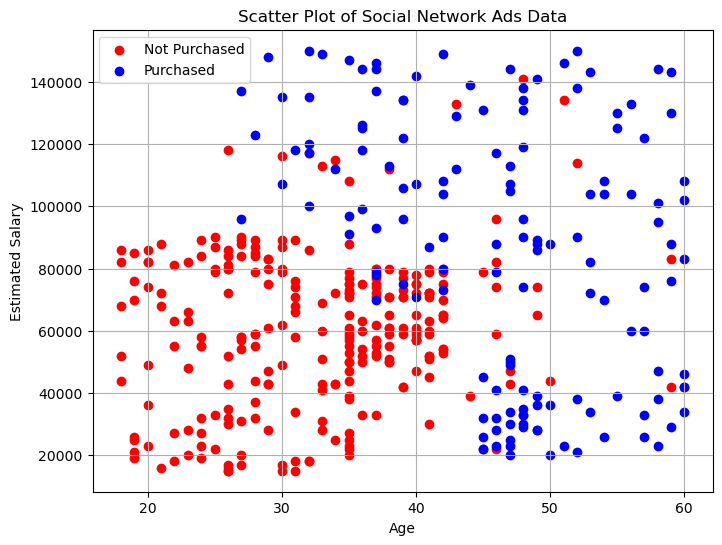

In [38]:

plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', label='Not Purchased')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Purchased')

plt.title('Scatter Plot of Social Network Ads Data')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.grid(True)
plt.show()

### Splitting the dataset into the Training set and Test set

In [23]:
from sklearn.model_selection import train_test_split
X_Train, X_Test, y_Train, y_Test = train_test_split(X, y, test_size = 0.25, random_state = 0)

### Feature Scaling

In [24]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_Train = sc_X.fit_transform(X_Train)
X_Test = sc_X.transform(X_Test)

### Fitting the classifier into the Training set

In [39]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear', random_state = 0)
SVM_Classifier = classifier.fit(X_Train, y_Train)

### Predicting the test set results

In [40]:
Y_Pred = SVM_Classifier.predict(X_Test)

### Cofficient of Plane

In [53]:
Cofficient = SVM_Classifier.coef_
Cofficient

array([[1.60291291, 0.97138722]])

### Intercept of the Plane

In [55]:
Intercept = SVM_Classifier.intercept_
Intercept

array([-0.76862169])

### Print the equation of the SVM plane

In [51]:
print("Equation of the SVM plane:")
print("Equation: ", end="")
for i, coef in enumerate(SVM_Classifier.coef_[0]):
    print(f"({coef:.2f} * X{i})", end=" ")
print(f"+ {SVM_Classifier.intercept_[0]:.2f} = 0")


Equation of the SVM plane:
Equation: (1.60 * X0) (0.97 * X1) + -0.77 = 0


# $$ f(X) = {(1.60 * X0) (0.97 * X1) + (-0.77))}$$

### Comparing predicted value & real value

In [41]:
df = pd.DataFrame({"Actual Value" : y_Test,
                "Predicted Value" : Y_Pred})
df

,Actual Value,Predicted Value
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
95,1,0
96,0,0
97,1,0
98,1,1


### Accuracy of the model

In [32]:
from sklearn.metrics import accuracy_score
Accuracy = accuracy_score(y_Test,Y_Pred)
print("Accuracy of the model",Accuracy*100)

Accuracy of the model 90.0


### Making the Confusion Matrix

In [34]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_Test, Y_Pred)
print(cm)

[[66  2]
 [ 8 24]]


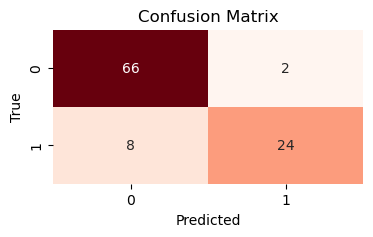

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_Test, Y_Pred)

# Plot confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


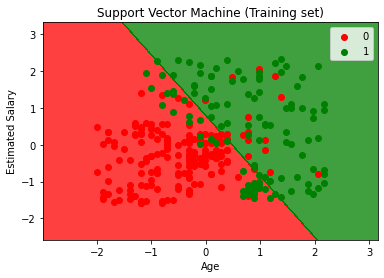

In [10]:
# Visualising the Training set results

from matplotlib.colors import ListedColormap
X_Set, Y_Set = X_Train, Y_Train
X1, X2 = np.meshgrid(np.arange(start = X_Set[:, 0].min() - 1, stop = X_Set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_Set[:, 1].min() - 1, stop = X_Set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_Set)):
    plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Support Vector Machine (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


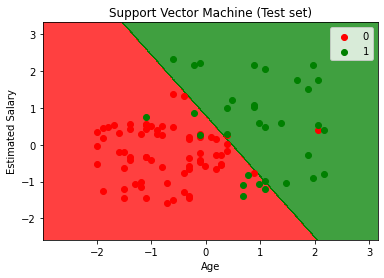

In [11]:
# Visualising the Test set results

from matplotlib.colors import ListedColormap
X_Set, Y_Set = X_Test, Y_Test
X1, X2 = np.meshgrid(np.arange(start = X_Set[:, 0].min() - 1, stop = X_Set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_Set[:, 1].min() - 1, stop = X_Set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_Set)):
    plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Support Vector Machine (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

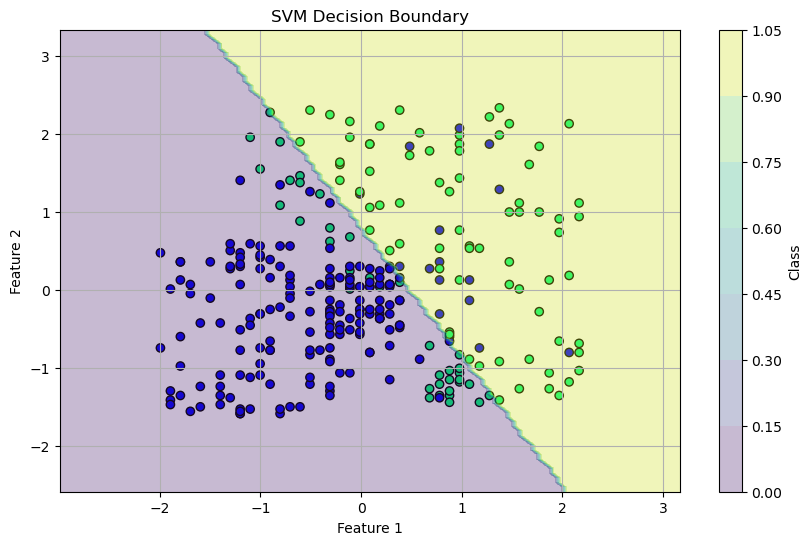

In [50]:
# Visualize the decision boundary
plt.figure(figsize=(10, 6))

# Plot the data points
plt.scatter(X_Train[:, 0], X_Train[:, 1], c=y_Train, cmap='winter', marker='o', edgecolors='k')

# Create a meshgrid to plot the decision boundary
xx, yy = np.meshgrid(np.linspace(X_Train[:, 0].min() - 1, X_Train[:, 0].max() + 1, 100),
                     np.linspace(X_Train[:, 1].min() - 1, X_Train[:, 1].max() + 1, 100))
Z = SVM_Classifier.predict(np.c_[xx.ravel(), yy.ravel()])

# Plot the decision boundary
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Decision Boundary')
plt.colorbar(label='Class')
plt.grid(True)
plt.show()